In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import defaultdict

# Clean

In [145]:
cdr = pd.read_csv('cdr_sample.csv')
celltower = pd.read_csv('celltower_location.csv')

In [146]:
d = cdr['date'].astype(str).str.zfill(6)
cdr['date'] = pd.to_datetime('20' + d.str[:2] + '-' + d.str[2:4] + '-' + d.str[4:6])

tower = dict(zip(celltower['antenna_id'], celltower['district']))

In [147]:
people = set(cdr['user_1'].unique())

c1= cdr[['user_1','date','tower_1']].copy()
c1.columns= ['id','date','tower']
c1['district']=c1['tower'].map(tower)

c2= cdr[['user_2','date','tower_2']].copy()
c2.columns= ['id','date','tower']
c2['district']=c2['tower'].map(tower)

clean = pd.concat([c1,c2], ignore_index=True)
clean = clean[['id','date','district']]
clean = clean.dropna(subset=['district'])
clean = clean[clean['id'].isin(people)] 
clean = clean.drop_duplicates(subset=['id','date','district'])
print(clean.head())
print(clean['id'].nunique())
print(clean['date'].min(), clean['date'].max())

          id       date    district
0  L55737047 2008-06-17      Rusizi
1  L55737047 2008-07-30  Nyamasheke
2  L55737047 2008-04-22  Nyamasheke
3  L55737047 2008-04-08      Rusizi
4  L55737047 2008-01-23      Rusizi
3610
2007-08-01 00:00:00 2008-07-31 00:00:00


In [148]:
# number for every day
every = pd.date_range(clean['date'].min(), clean['date'].max(), freq='D')

num = {}
for i,d in enumerate(every):
    num[pd.Timestamp(d)] = i

clean['number'] = clean['date'].map(num)

oneday = {}
for row in clean.itertuples(index=False):
    if row.id not in oneday:
        oneday[row.id] = {}
    if row.number not in oneday[row.id]:
        oneday[row.id][row.number] = set()

    oneday[row.id][row.number].add(row.district)


In [149]:
# epsilon
def fillin(inoneday, epsilon=7):
    if not inoneday:
        return {}
    fill2 = dict(inoneday)
    days = sorted(inoneday.keys())
    for i in range(len(days) - 1):
        gap = days[i+1]-days[i] - 1
        if 0<gap<= epsilon:
            for d in range(days[i] + 1, days[i+1]):
                fill2[d]=inoneday[days[i]]
    return fill2

In [150]:
# at leat 30 days for a segments
def find_segments(filled_dict, min_days=30):
    if not filled_dict:
        return {}
    district_days = defaultdict(list)
    for day, districts in filled_dict.items():
        for d in districts:
            district_days[d].append(day) 
    segments = {}
    for district, days in district_days.items():
        days = sorted(days)
        segs = []
        seg_start = days[0]
        seg_end = days[0]
        for day in days[1:]:
            if day == seg_end + 1:
                seg_end = day
            else:
                if seg_end - seg_start + 1 >= min_days:
                    segs.append((seg_start, seg_end))
                seg_start = day
                seg_end = day
        if seg_end - seg_start + 1 >= min_days:
            segs.append((seg_start, seg_end))
        if segs:
            segments[district] = segs
    return segments


In [151]:
def filter_seg_by_prop(raw_daily, segments, prop=0.6):
    filtered = {}
    for district, segs in segments.items():
        valid_segs = []
        for (start, end) in segs:
            length = end - start + 1
            actual_days = sum(
                1 for day in range(start, end + 1)
                if day in raw_daily and district in raw_daily[day]
            )
            if actual_days >= prop * length:
                valid_segs.append((start, end))
        if valid_segs:
            filtered[district] = valid_segs
    return filtered

In [152]:
def merge_segments(segments):
    if not segments:
        return {}
    
    merged = {}
    for district, segs in segments.items():
        segs = sorted(segs, key=lambda x: x[0])
        result = [segs[0]]
        for seg in segs[1:]:
            prev = result[-1]
            gap_start = prev[1] + 1
            gap_end = seg[0] - 1
            has_other = False
            for other_d, other_segs in segments.items():
                if other_d == district:
                    continue
                for (os, oe) in other_segs:
                    if os <= gap_end and oe >= gap_start:
                        has_other = True
                        break
                if has_other:
                    break
            if not has_other:
                result[-1] = (prev[0], max(prev[1], seg[1]))
            else:
                result.append(seg)
        merged[district] = result
    return merged


In [153]:
def remove_overlap_and_filter(segments, k=90):
    all_segs = []
    for district, segs in segments.items():
        for (s, e) in segs:
            all_segs.append((s, e, district, e - s + 1))
    
    if not all_segs:
        return {}
    all_segs.sort(key=lambda x: -x[3])
    day_owner = {}
    for (s, e, district, length) in all_segs:
        for day in range(s, e + 1):
            if day not in day_owner:
                day_owner[day] = district
    if not day_owner:
        return {}
    
    days_sorted = sorted(day_owner.keys())
    result = defaultdict(list)
    seg_start = days_sorted[0]
    seg_dist = day_owner[days_sorted[0]]
    
    for day in days_sorted[1:]:
        current_dist = day_owner[day]
        if day == days_sorted[days_sorted.index(day) - 1] + 1 and current_dist == seg_dist:
            pass 
        else:
            length = day - 1 - seg_start + 1 
            if length >= k:
                result[seg_dist].append((seg_start, day - 1))
            seg_start = day
            seg_dist = current_dist

    last_day = days_sorted[-1]
    length = last_day - seg_start + 1
    if length >= k:
        result[seg_dist].append((seg_start, last_day))
    
    return dict(result)

In [154]:
def remove_overlap_and_filter_v2(segments, k=90):
    all_segs = []
    for district, segs in segments.items():
        for (s, e) in segs:
            all_segs.append((s, e, district, e - s + 1))   
    if not all_segs:
        return {}
    all_segs.sort(key=lambda x: -x[3])
    day_owner = {}
    for (s, e, district, _) in all_segs:
        for day in range(s, e + 1):
            if day not in day_owner:
                day_owner[day] = district
    if not day_owner:
        return {}
    days_sorted = sorted(day_owner.keys())
    result = defaultdict(list)
    seg_start = days_sorted[0]
    seg_dist = day_owner[days_sorted[0]]
    prev_day = days_sorted[0]
    
    for day in days_sorted[1:]:
        current_dist = day_owner[day]
        if day == prev_day + 1 and current_dist == seg_dist:
            prev_day = day
        else:
            length = prev_day - seg_start + 1
            if length >= k:
                result[seg_dist].append((seg_start, prev_day))
            seg_start = day
            seg_dist = current_dist
            prev_day = day
    
    length = prev_day - seg_start + 1
    if length >= k:
        result[seg_dist].append((seg_start, prev_day))
    
    return dict(result)


In [155]:
def find_migrations(long_segments):
    all_segs = []
    for district, segs in long_segments.items():
        for (s, e) in segs:
            all_segs.append((s, e, district))
    all_segs.sort(key=lambda x: x[0])
    
    migrations = []
    for i in range(len(all_segs) - 1):
        s1, e1, d1 = all_segs[i]
        s2, e2, d2 = all_segs[i+1]
        if d1 != d2:
            migrations.append((d1, s1, e1, d2, s2, e2))
    return migrations


In [156]:
def find_migration_date(home_end, dest_start, raw_daily, home_dist, dest_dist):
    if dest_start <= home_end:
        overlap_start = dest_start
        overlap_end = home_end
        best_t = overlap_start
        best_errors = float('inf')
        
        for t in range(overlap_start, overlap_end + 2):
            errors = 0
            for day in range(overlap_start, overlap_end + 1):
                if day in raw_daily:
                    if day < t and dest_dist in raw_daily[day]:
                        errors += 1
                    if day >= t and home_dist in raw_daily[day]:
                        errors += 1
            if errors <= best_errors:
                best_errors = errors
                best_t = t
        uncertainty = 0
    else:
        best_t = (home_end + dest_start) // 2
        uncertainty = dest_start - home_end - 1
    
    return best_t, uncertainty


# Run

In [157]:
EPSILON = 7
MIN_DAYS = 30
PROP_DAYS = 0.6
K = 90
MAX_GAP = 30

print(f" ε={EPSILON}, minDays={MIN_DAYS}, propDays={PROP_DAYS}, k={K}")

 ε=7, minDays=30, propDays=0.6, k=90


In [158]:
all_migrations = []
users = list(oneday.keys())

for i, id in enumerate(users):
    if i % 500 == 0:
        print(f"{i}/{len(users)}")
    
    raw_daily = oneday[id]  
    
    fill2 = fillin(raw_daily, epsilon=EPSILON)
    segs = find_segments(fill2, min_days=MIN_DAYS)

    segs = filter_seg_by_prop(raw_daily, segs, prop=PROP_DAYS)
    
    segs = merge_segments(segs)
    
    long_segs = remove_overlap_and_filter_v2(segs, k=K)
    
    if len(long_segs) < 2:
        continue  
   
    migrations = find_migrations(long_segs)
    
    for (home_d, home_s, home_e, dest_d, dest_s, dest_e) in migrations:
        gap = dest_s - home_e - 1
        if gap > MAX_GAP:
            continue  
        
        mig_day, uncertainty = find_migration_date(
            home_e, dest_s, raw_daily, home_d, dest_d
        )
        idx2date = {i: d for d, i in num.items()}
        all_migrations.append({
            'id': id,
            'home': home_d,
            'destination': dest_d,
            'home_start': idx2date[home_s],
            'home_end': idx2date[home_e],
            'destination_start': idx2date[dest_s],
            'destination_end': idx2date[dest_e],
            'migration_date': idx2date[mig_day],
            'uncertainty_days': uncertainty,
            'gap_days': gap
        })

migrants_df = pd.DataFrame(all_migrations)
print(f"{len(migrants_df)} ")
print(f"{migrants_df['id'].nunique() if len(migrants_df) > 0 else 0}")
print(migrants_df.head())

0/3610
500/3610
1000/3610
1500/3610
2000/3610
2500/3610
3000/3610
3500/3610
49 
49
          id        home destination home_start   home_end destination_start  \
0  L52822047  Nyamasheke      Rusizi 2007-08-01 2008-01-08        2008-01-23   
1  L50507890      Rusizi      Kigali 2007-10-15 2008-01-26        2008-02-21   
2  L80045916  Nyamasheke      Rusizi 2007-08-02 2008-01-18        2008-01-19   
3  L21861102      Rusizi     Kayonza 2007-08-01 2008-04-01        2008-04-04   
4  L01803287  Nyamasheke      Rusizi 2007-08-10 2008-01-30        2008-02-16   

  destination_end migration_date  uncertainty_days  gap_days  
0      2008-06-12     2008-01-15                14        14  
1      2008-07-13     2008-02-08                25        25  
2      2008-07-31     2008-01-18                 0         0  
3      2008-07-31     2008-04-02                 2         2  
4      2008-06-27     2008-02-07                16        16  


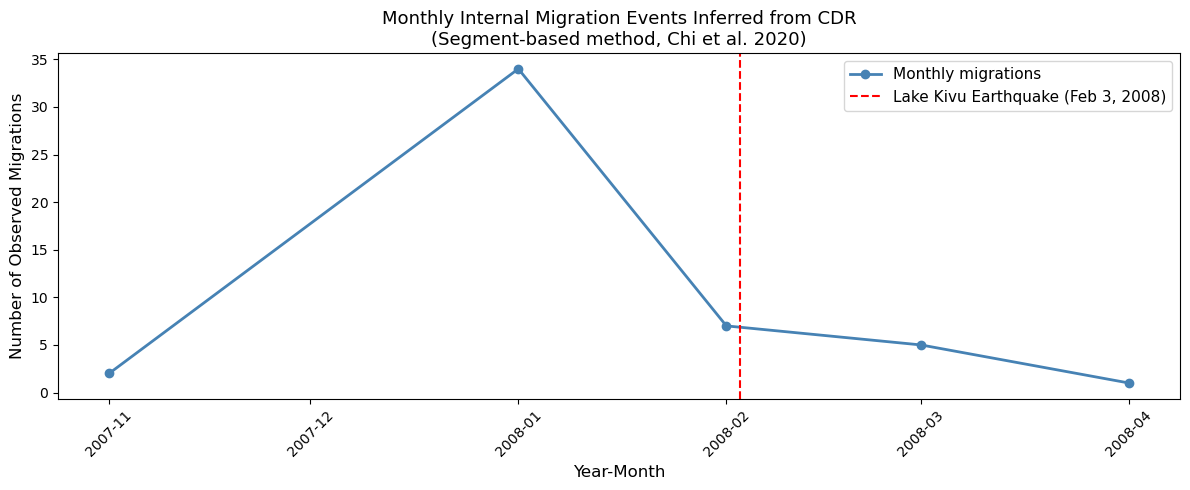

In [159]:
migrants_df['migration_month'] = pd.to_datetime(
    migrants_df['migration_date']
).dt.to_period('M')

monthly = (migrants_df
           .groupby('migration_month')
           .size()
           .reset_index(name='n_migrations'))
monthly['month_dt'] = monthly['migration_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly['month_dt'], monthly['n_migrations'],
        marker='o', linewidth=2, color='steelblue', label='Monthly migrations')


earthquake_date = pd.Timestamp('2008-02-03')
ax.axvline(x=earthquake_date, color='red', linestyle='--',
           linewidth=1.5, label='Lake Kivu Earthquake (Feb 3, 2008)')

ax.set_xlabel('Year-Month', fontsize=12)
ax.set_ylabel('Number of Observed Migrations', fontsize=12)
ax.set_title('Monthly Internal Migration Events Inferred from CDR\n(Segment-based method, Chi et al. 2020)',
             fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('migration_timeseries.png', dpi=150)
plt.show()